#Libraries

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

# Load Data

In [2]:
!unzip -q data.zip

datasetLink: https://www.kaggle.com/datasets/anupamshah/perrin-freres-monthly-champagne-sales/data

In [4]:
df=pd.read_csv('/content/perrin-freres-monthly-champagne.csv')
df.head()

,Month,Perrin Freres monthly champagne sales millions ?64-?72
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


# data Cleaning

In [5]:
df.columns=['Month','Sales']
df.head()

,Month,Sales
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


In [6]:
df.shape

(107, 2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Month   106 non-null    object 
 1   Sales   105 non-null    float64
dtypes: float64(1), object(1)
memory usage: 1.8+ KB


In [13]:
df[df.isnull().any(axis=1)]

,Month,Sales
105,NaN,NaN
106,Perrin Freres monthly champagne sales millions...,NaN


In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

,0
Month,0
Sales,0


In [17]:
df.tail()

,Month,Sales
100,1972-05,4618.0
101,1972-06,5312.0
102,1972-07,4298.0
103,1972-08,1413.0
104,1972-09,5877.0


In [19]:
df.dtypes

,0
Month,object
Sales,float64


In [20]:
df['Month']=pd.to_datetime(df['Month'])

In [21]:
df.dtypes

,0
Month,datetime64[ns]
Sales,float64


In [23]:
df.set_index('Month',inplace=True)

In [24]:
df.index

DatetimeIndex(['1964-01-01', '1964-02-01', '1964-03-01', '1964-04-01',
               '1964-05-01', '1964-06-01', '1964-07-01', '1964-08-01',
               '1964-09-01', '1964-10-01',
               ...
               '1971-12-01', '1972-01-01', '1972-02-01', '1972-03-01',
               '1972-04-01', '1972-05-01', '1972-06-01', '1972-07-01',
               '1972-08-01', '1972-09-01'],
              dtype='datetime64[ns]', name='Month', length=105, freq=None)

In [26]:
df=df.asfreq('MS')

In [27]:
df.index

DatetimeIndex(['1964-01-01', '1964-02-01', '1964-03-01', '1964-04-01',
               '1964-05-01', '1964-06-01', '1964-07-01', '1964-08-01',
               '1964-09-01', '1964-10-01',
               ...
               '1971-12-01', '1972-01-01', '1972-02-01', '1972-03-01',
               '1972-04-01', '1972-05-01', '1972-06-01', '1972-07-01',
               '1972-08-01', '1972-09-01'],
              dtype='datetime64[ns]', name='Month', length=105, freq='MS')

# Visulize

<Axes: xlabel='Month'>

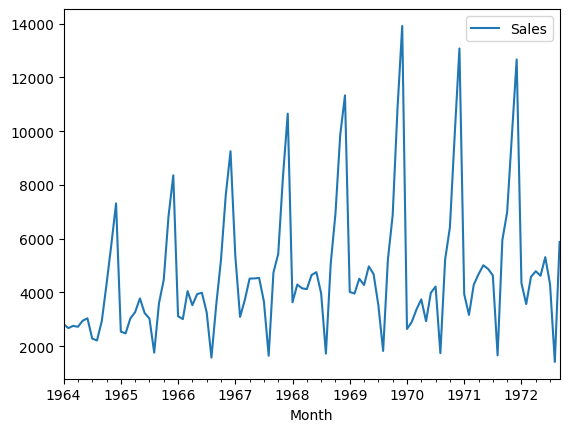

In [28]:
df.plot()

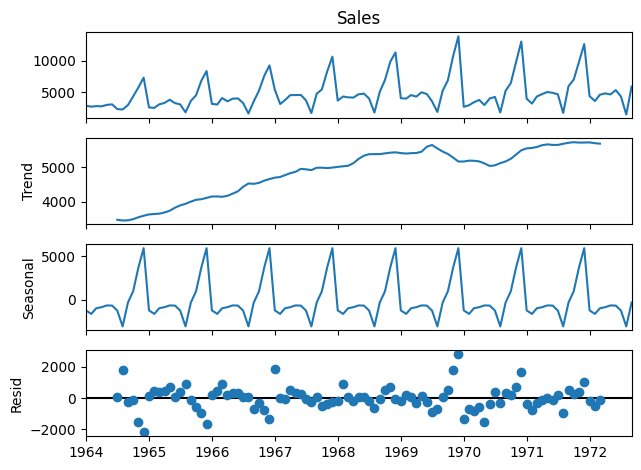

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

result = seasonal_decompose(df['Sales'], model='additive', period=12)

# 3. Plot the components
result.plot()
plt.show()

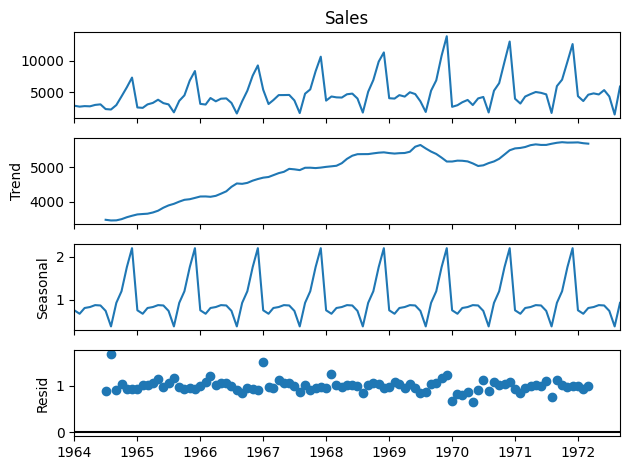

In [31]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

result = seasonal_decompose(df['Sales'], model='mul', period=12)

# 3. Plot the components
result.plot()
plt.show()

 Multiplicative model will better explain the data


In [37]:
from statsmodels.graphics.tsaplots import month_plot,quarter_plot

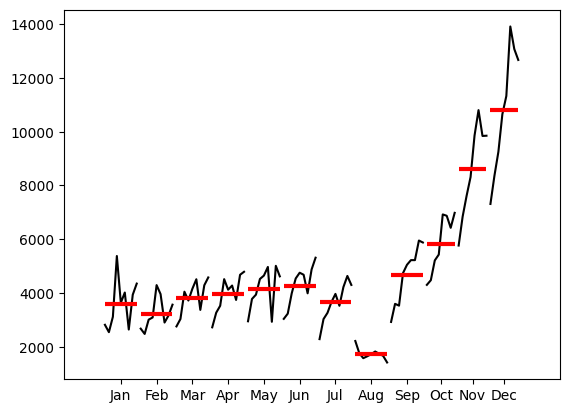

In [39]:
month_plot(df['Sales'])
plt.show()

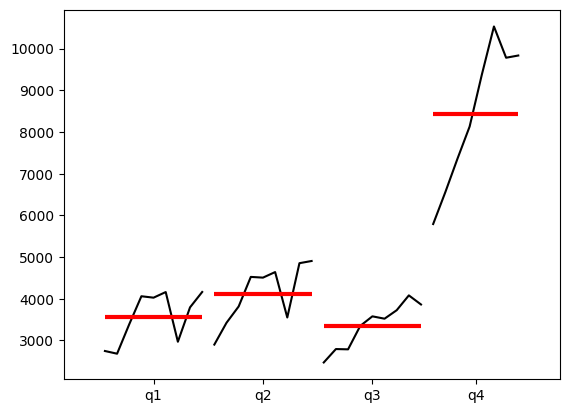

In [41]:
quarter_plot(df['Sales'].resample('Q').mean())
plt.show()

# Sationarity Check

In [32]:
def adf_test(series):
    result = adfuller(series.dropna())

    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("Critical Values:")
    for key, val in result[4].items():
        print(f"   {key}: {val}")

    # Interpretation
    if result[1] < 0.05:
        print("✅ Data is Stationary")
    else:
        print("❌ Data is Non-Stationary")


In [33]:
adf_test(df['Sales'])

ADF Statistic: -1.8335930563276215
p-value: 0.36391577166024586
Critical Values:
   1%: -3.502704609582561
   5%: -2.8931578098779522
   10%: -2.583636712914788
❌ Data is Non-Stationary


In [35]:
df['Sales first diff']=df['Sales']-df['Sales'].shift(1)

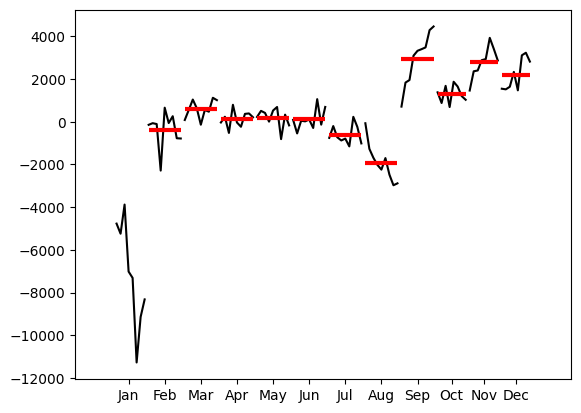

In [42]:
month_plot(df['Sales first diff'])
plt.show()

In [43]:
adf_test(df['Sales first diff'])

ADF Statistic: -7.189896448050999
p-value: 2.519620447387081e-10
Critical Values:
   1%: -3.503514579651927
   5%: -2.893507960466837
   10%: -2.583823615311909
✅ Data is Stationary


In [36]:
df.head()

,Sales,Sales first diff
Month,,
1964-01-01,2815.0,NaN
1964-02-01,2672.0,-143.0
1964-03-01,2755.0,83.0
1964-04-01,2721.0,-34.0
1964-05-01,2946.0,225.0


In [44]:
df['Seasonal first diff']=df['Sales']-df['Sales'].shift(12)

In [45]:
df.head(7)

,Sales,Sales first diff,Seasonal first diff
Month,,,
1964-01-01,2815.0,NaN,NaN
1964-02-01,2672.0,-143.0,NaN
1964-03-01,2755.0,83.0,NaN
1964-04-01,2721.0,-34.0,NaN
1964-05-01,2946.0,225.0,NaN
1964-06-01,3036.0,90.0,NaN
1964-07-01,2282.0,-754.0,NaN


In [46]:
adf_test(df['Seasonal first diff'])

ADF Statistic: -7.626619157213166
p-value: 2.0605796968136632e-11
Critical Values:
   1%: -3.503514579651927
   5%: -2.893507960466837
   10%: -2.583823615311909
✅ Data is Stationary


# ACF & PACF plot

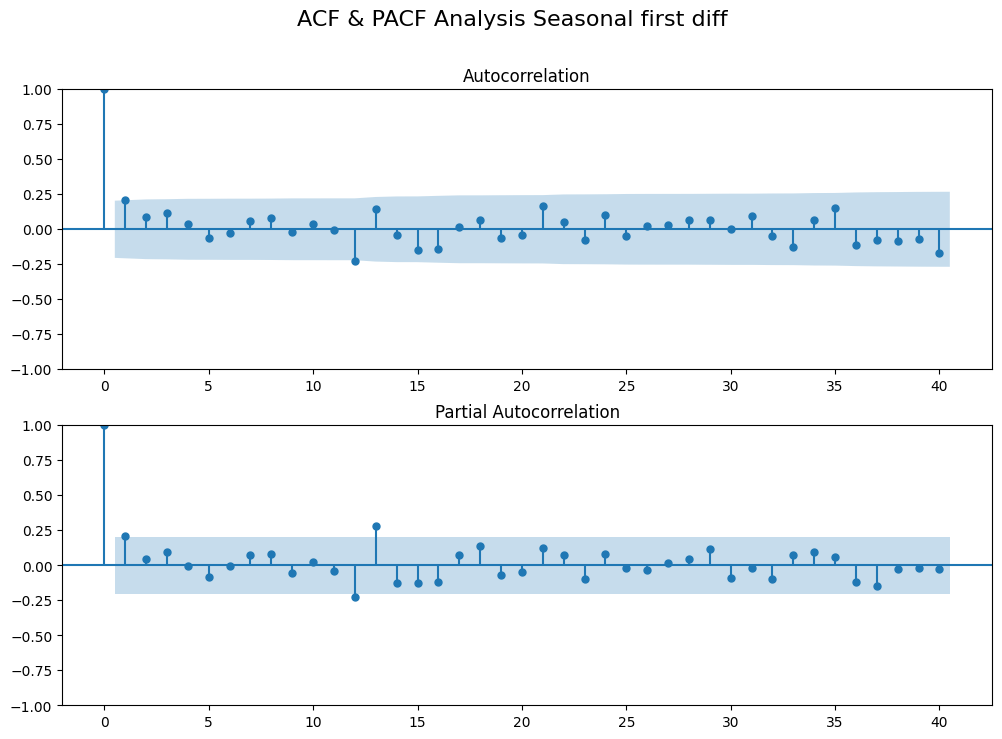

In [52]:

fig = plt.figure(figsize = (12,8))
fig.suptitle("ACF & PACF Analysis Seasonal first diff", fontsize=16)
ax1 = fig.add_subplot(211)
fig = plot_acf(df['Seasonal first diff'].iloc[13:], lags=40, ax=ax1)

ax2 = fig.add_subplot(212)
fig = plot_pacf(df['Seasonal first diff'].iloc[13:], lags=40, ax=ax2)
plt.show()

Text(0.5, 1.0, 'Sales first diff')

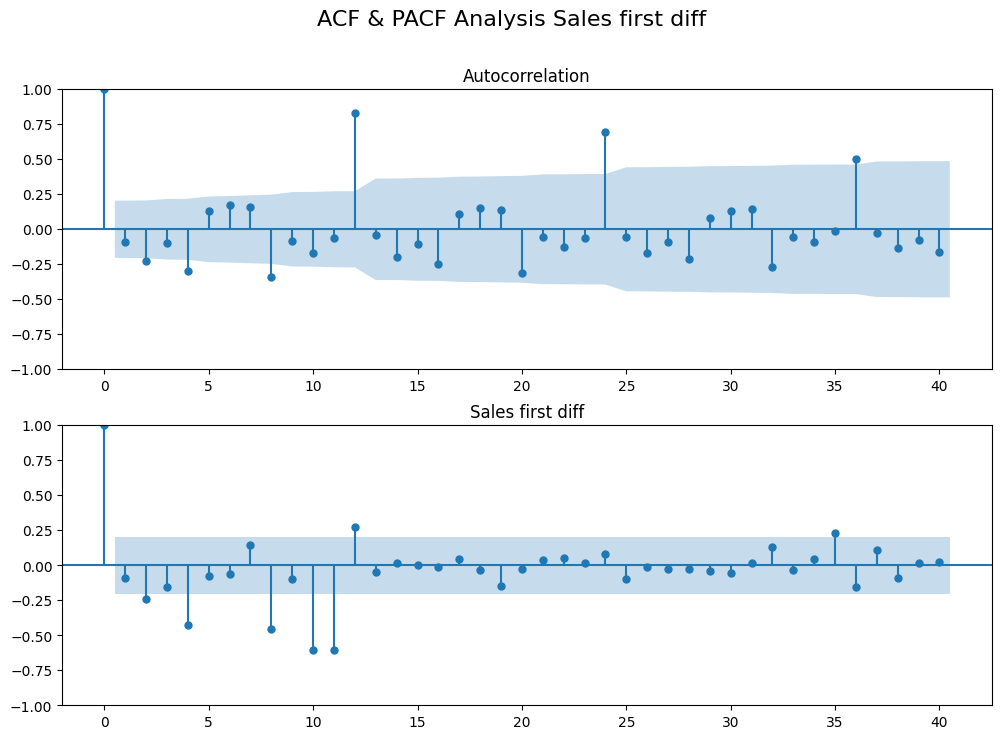

In [53]:

fig = plt.figure(figsize = (12,8))
fig.suptitle("ACF & PACF Analysis Sales first diff", fontsize=16)
ax1 = fig.add_subplot(211)
fig = plot_acf(df['Sales first diff'].iloc[13:], lags=40, ax=ax1)

ax2 = fig.add_subplot(212)
fig = plot_pacf(df['Sales first diff'].iloc[13:], lags=40, ax=ax2)
plt.title('Sales first diff')

# Model

In [69]:
# 80% train, 20% test
train_size = int(len(df) * 0.8)

train = df['Sales'][:train_size]
test = df['Sales'][train_size:]

In [70]:
from statsmodels.tsa.arima.model import ARIMA

In [71]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   84
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -757.967
Date:                Sat, 02 May 2026   AIC                           1521.934
Time:                        03:02:19   BIC                           1529.190
Sample:                    01-01-1964   HQIC                          1524.849
                         - 12-01-1970                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5459      0.172      3.166      0.002       0.208       0.884
ma.L1         -0.9539      0.105     -9.093      0.000      -1.160      -0.748
sigma2      4.934e+06   6.27e+05      7.865      0.0

In [72]:
start = len(train)
end = len(train) + len(test) - 1

predictions = model_fit.predict(start=start, end=end, typ='levels')
predictions.index = test.index

In [76]:
from sklearn.metrics import mean_squared_error

In [77]:
rmse = np.sqrt(mean_squared_error(test, predictions))
print("RMSE:", rmse)

RMSE: 3018.734441011594


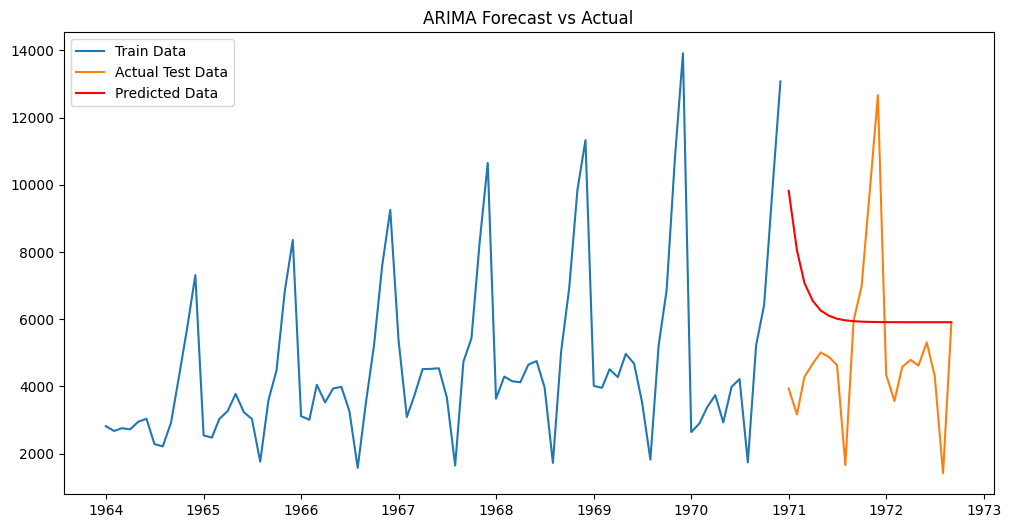

In [78]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Train Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(test.index, predictions, label='Predicted Data', color='red')

plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.show()

# Sarimax

In [79]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [80]:
model_sr = ARIMA(train, order=(1,1,1), seasonal_order=(1,1,1,12))
model_fitsr = model_sr.fit()

print(model_fitsr.summary())

                                    SARIMAX Results                                     
Dep. Variable:                            Sales   No. Observations:                   84
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -573.776
Date:                          Sat, 02 May 2026   AIC                           1157.551
Time:                                  03:06:53   BIC                           1168.864
Sample:                              01-01-1964   HQIC                          1162.050
                                   - 12-01-1970                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2117      0.113      1.872      0.061      -0.010       0.433
ma.L1         -0.9085      0.076    -11.948      0.

In [81]:
start = len(train)
end = len(train) + len(test) - 1

predictions = model_fitsr.predict(start=start, end=end, typ='levels')
predictions.index = test.index

In [82]:
rmse = np.sqrt(mean_squared_error(test, predictions))
print("RMSE:", rmse)

RMSE: 1187.787554710434


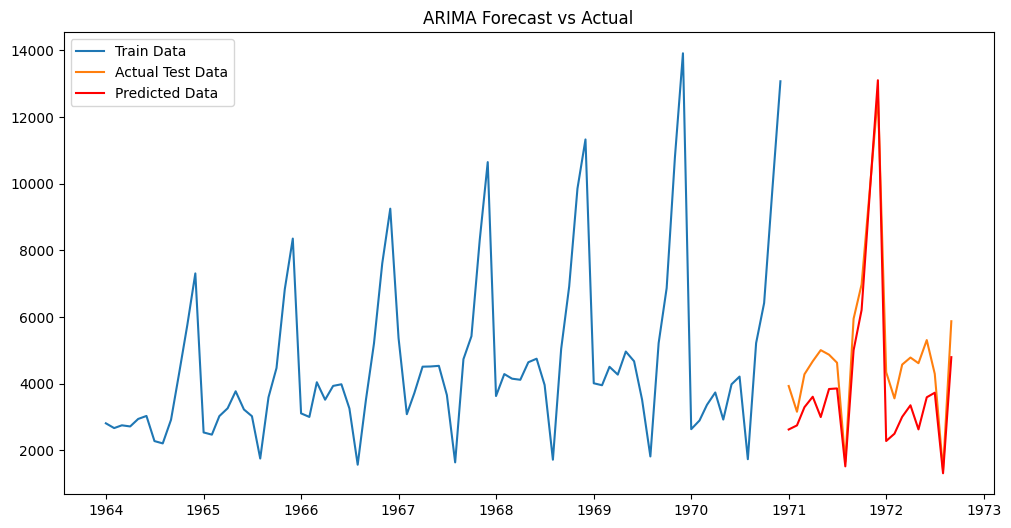

In [83]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Train Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(test.index, predictions, label='Predicted Data', color='red')

plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.show()